--- Dataset Info ---
Date         321
State        140
Region       321
Confirmed    321
Deaths       321
Recovered    321
dtype: int64

--- Missing Values ---
Date           0
State        181
Region         0
Confirmed      0
Deaths         0
Recovered      0
dtype: int64


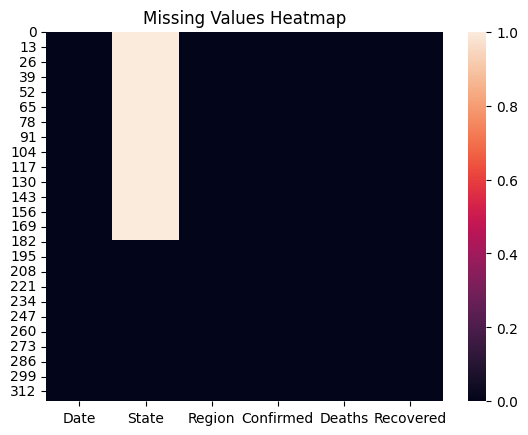


--- Region Summary ---
                    Confirmed  Deaths  Recovered
Region                                          
Afghanistan              1939      60        252
Albania                   766      30        455
Algeria                  3848     444       1702
Andorra                   743      42        423
Angola                     27       2          7
...                       ...     ...        ...
West Bank and Gaza        344       2         71
Western Sahara              6       0          5
Yemen                       6       0          1
Zambia                     97       3         54
Zimbabwe                   32       4          5

[187 rows x 3 columns]

Max Confirmed Region: Region
US    1039909
Name: Confirmed, dtype: int64
Min Deaths Region: Region
Cambodia    0
Name: Deaths, dtype: int64

--- India Status ---
         Date State Region  Confirmed  Deaths  Recovered
74  4/29/2020   NaN  India      33062    1079       8437


In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Load Data
df = pd.read_csv('Covid_19_data.csv')

# 2. Initial Exploration & Visualization
print("--- Dataset Info ---")
print(df.count())
print("\n--- Missing Values ---")
print(df.isnull().sum())

# Visualizing missing data
sns.heatmap(df.isnull())
plt.title("Missing Values Heatmap")
plt.show()

# Q. 1) Number of Confirmed, Deaths and Recovered cases in each Region
region_summary = df.groupby('Region')[['Confirmed', 'Deaths', 'Recovered']].sum()
print("\n--- Region Summary ---")
print(region_summary)

# Q. 2) Remove records where Confirmed Cases < 10
df = df[~(df.Confirmed < 10)]

# Q. 3) Region with Maximum Confirmed cases
max_confirmed = df.groupby('Region').Confirmed.sum().sort_values(ascending=False).head(1)
print(f"\nMax Confirmed Region: {max_confirmed}")

# Q. 4) Region with Minimum Deaths recorded
min_deaths = df.groupby('Region').Deaths.sum().sort_values(ascending=True).head(1)
print(f"Min Deaths Region: {min_deaths}")

# Q. 5) India status till 29 April 2020
india_data = df[df.Region == 'India']
print("\n--- India Status ---")
print(india_data)

# Q. 6-A) Sort by Confirmed cases (Ascending)
df_sorted_confirmed = df.sort_values(by=['Confirmed'], ascending=True)

# Q. 6-B) Sort by Recovered cases (Descending)
df_sorted_recovered = df.sort_values(by=['Recovered'], ascending=False)